# Hierarchical State-Space Forecasting

`HierarchicalSSM` is the panel (multi-item) version of `UnivariateSSM`. All items
are fitted **jointly** in one multivariate structural state-space model, and two
families of parameters are **partially pooled** across items via hierarchical
hyper-priors:

* the **seasonal amplitudes** (each item's weekly shape), and
* the **regression coefficients** on shared covariates (e.g. a promotion).

Everything else — each item's level, trend, and noise variances — stays
independent per item. The payoff is *shrinkage*: an item with a short or noisy
history borrows its seasonal shape and covariate response from the population, so
its estimates are pulled toward the group instead of overfitting its handful of
observations.

This notebook, on synthetic data where we know the ground truth, shows:

1. **Parameter shrinkage** — one "new launch" item with far less data.
2. **Forecasting** and extracting per-item **demand distributions**.
3. How to **change the priors** (the pooling strength) without refitting.

> Fitted with `log_transform=True` throughout, so every forecast is non-negative.

## 1. A synthetic panel with a data-starved item

Four bakery articles share a **common weekly shape** and a **common promo
lift** (drawn from tight populations, so the population truth is essentially each
item's truth). Three have ~5 months of daily history; **`new_launch`** has only
its last 18 days — far too few to identify a weekly cycle or a promo effect on its
own. A single shared `promo` indicator drives every item.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)

ITEMS = ["sourdough", "baguette", "croissant", "new_launch"]
BASE = {"sourdough": 70.0, "baguette": 55.0, "croissant": 40.0, "new_launch": 32.0}
N_FULL = 160          # days of history for established items
N_SPARSE = 18         # new_launch: only its last 18 days are observed
HORIZON = 14          # forecast horizon (also how far ahead promo is known)

# Ground-truth shared structure
WEEKLY = np.array([1.45, 1.00, 0.80, 0.90, 1.10, 1.40, 1.70])  # Mon..Sun multiplier
TRUE_PROMO_LIFT = 0.30                                          # + ~35% on promo days (log scale)

dates = pd.date_range("2022-01-03", periods=N_FULL + HORIZON, freq="D")  # starts Monday
dow = dates.dayofweek.to_numpy()
promo = (rng.random(N_FULL + HORIZON) < 0.25).astype(float)     # shared covariate

def series(base):
    weekly = WEEKLY[dow] * np.exp(rng.normal(0, 0.02, len(dates)))  # tiny per-item shape noise
    mu = base * weekly * np.exp(TRUE_PROMO_LIFT * promo)
    return np.maximum(1.0, mu * np.exp(rng.normal(0, 0.06, len(dates))))

full = pd.DataFrame({it: series(BASE[it]) for it in ITEMS}, index=dates)
full["promo"] = promo

# Split off the forecast horizon; blank all but the last N_SPARSE days of new_launch
panel = full.iloc[:N_FULL].copy()
panel.loc[panel.index[: N_FULL - N_SPARSE], "new_launch"] = np.nan

obs_counts = panel[ITEMS].notna().sum()
print("Observed days per item:")
print(obs_counts.to_string())
print(f"\nPromo days in training: {int(panel['promo'].sum())} of {N_FULL}")
panel.tail(3)

Observed days per item:
sourdough     160
baguette      160
croissant     160
new_launch     18

Promo days in training: 54 of 160


,sourdough,baguette,croissant,new_launch,promo
2022-06-09,60.703947,44.297331,35.404459,28.051270,0.0
2022-06-10,78.378197,60.798332,42.517497,36.049017,0.0
2022-06-11,103.686523,67.701425,52.189983,46.333029,0.0


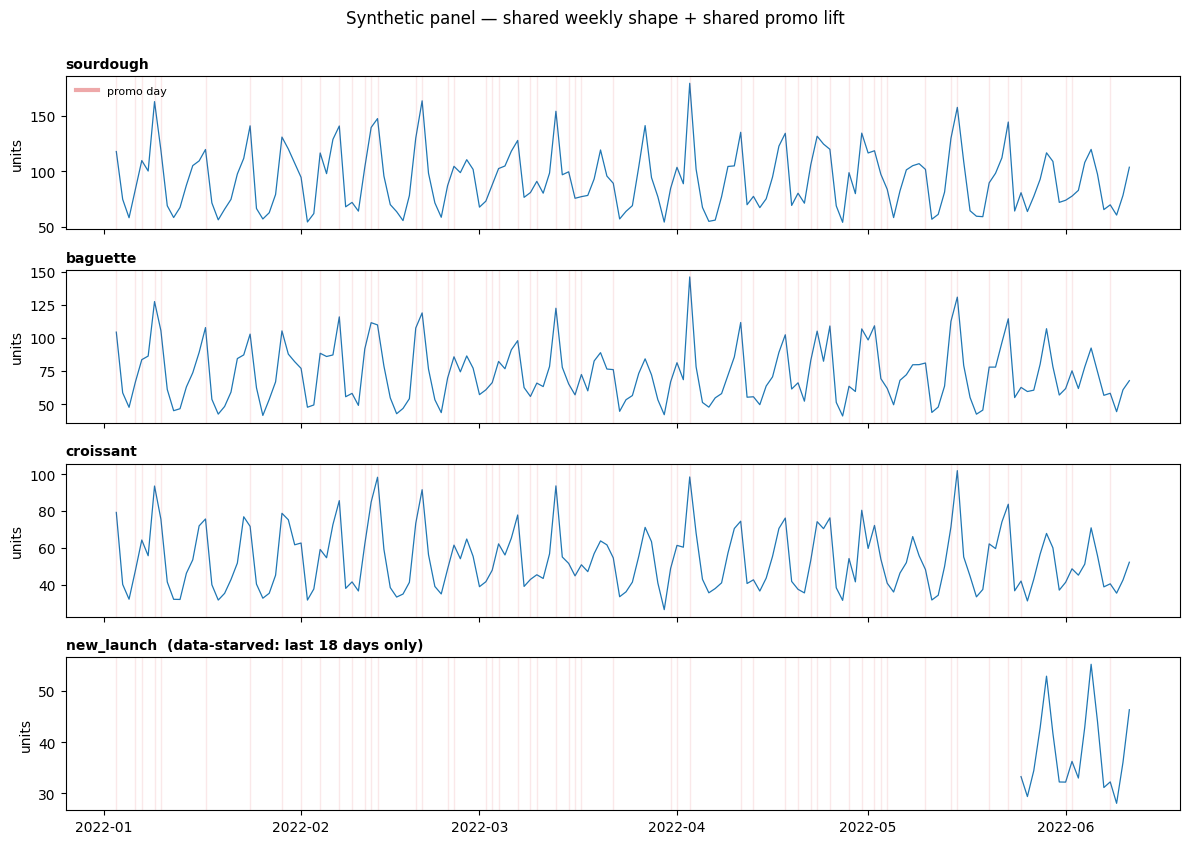

In [2]:
fig, axes = plt.subplots(len(ITEMS), 1, figsize=(12, 2.1 * len(ITEMS)), sharex=True)
for ax, it in zip(axes, ITEMS):
    ax.plot(panel.index, panel[it], lw=0.9, color="C0")
    for d in panel.index[panel["promo"] == 1]:
        ax.axvline(d, color="C3", alpha=0.10, lw=1)
    ax.set_ylabel("units")
    ax.set_title(it + ("  (data-starved: last 18 days only)" if it == "new_launch" else ""),
                 loc="left", fontsize=10, fontweight="bold")
axes[0].plot([], [], color="C3", alpha=0.4, lw=3, label="promo day")
axes[0].legend(loc="upper left", frameon=False, fontsize=8)
fig.suptitle("Synthetic panel — shared weekly shape + shared promo lift", y=1.0)
fig.tight_layout()

## 2. Fit the hierarchical model

Wide input (one column per item plus the `promo` column), `exog=["promo"]`,
weekly seasonality. A high `target_accept` is the recommended setting for the
hierarchy's funnel geometry — a few divergences here are normal, and raising
`target_accept` further or tightening the population-spread priors reduces them.

In [3]:
from optistock.forecasting import HierarchicalSSM

model = HierarchicalSSM(panel, items=ITEMS, exog=["promo"], log_transform=True)
model.build_model(seasonal_period=7, seasonal_harmonics=2)
model.fit(chains=2, draws=500, tune=1000, target_accept=0.99, progressbar=False)

div = int(model.idata.sample_stats["diverging"].sum())
print(f"Sampling done — {div} divergences")

                                           Model Requirements                                            
                                                                                                         
  Variable              Shape       Constraints                                              Dimensions  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (4, 2)                               ('endog_level_trend', 'state_level_trend')  
  sigma_level_trend     (4, 1)      Positive                 ('endog_level_trend', 'shock_level_trend')  
  beta_promo            (4, 1)                                           ('endog_promo', 'state_promo')  
  params_seasonal       (4, 4)                                     ('endog_seasonal', 'state_seasonal')  
  sigma_obs             (4,)        Positive                                             ('endog_obs',)  
  P0                    (28, 28)    Positive semi-definite                       ('state', 'state_aux')  
                                                                                                         
  data_promo            (None, 1)   pm.Data                                     ('time', 'state_promo')  
                                                                                                         
         These parameters should be assigned priors inside a PyMC model block before calling the         
                                     build_statespace_graph method.                                      

C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Sampling done — 0 divergences


## 3. Shrinkage: learning a weekly shape from little data

The cleanest way to see "less data for one item" is the **weekly seasonal
shape**. It is a strong signal (weekday demand swings roughly 2×), so a data-rich
item pins it down easily — but `new_launch`, with only 18 days, cannot. We
reconstruct each item's weekly shape from a **promo-off forecast** (promo set to
zero, leaving only seasonality), and compare it to the true shape for the pooled
model versus an ordinary `UnivariateSSM` fit **independently on each item's own
data**.

*(The promo coefficient is pooled too, but it is a poor shrinkage illustration
here: in a single flexible state-space series the intermittent promo signal is
weakly identified for* every *item — only pooling across items pins it down. The
weekly shape, being far stronger, isolates the "scarce vs. plentiful data" effect
cleanly.)*

In [4]:
from optistock.forecasting import UnivariateSSM

WsN = WEEKLY / WEEKLY.mean()            # true normalised weekly shape (Mon..Sun)
H = 28                                  # promo-off forecast horizon for shape recovery

def weekly_shape(daily_mean, dates):
    p = np.array([daily_mean[dates.dayofweek == d].mean() for d in range(7)])
    return p / p.mean()

# --- Pooled shapes: forecast every item with promo OFF, isolating seasonality ---
model.forecast(periods=H, scenario={"data_promo": np.zeros((H, 1))})
pool_dates = pd.DatetimeIndex(model.forecast_idata["time"].values)
pooled_shape = {}
for it in ITEMS:
    obs = model.forecast_idata["forecast_observed"].sel(observed_state=it)
    dm = model.inverse_transform(obs.stack(sample=["chain", "draw"])).mean("sample").values
    pooled_shape[it] = weekly_shape(dm, pool_dates)

# --- Unpooled shapes: fit each item's ordinary SSM alone, same reconstruction ---
unpooled_shape = {}
for it in ITEMS:
    di = panel[[it, "promo"]].dropna(subset=[it]).rename(columns={it: "sales"})
    m = UnivariateSSM(di, target_col="sales", exog={"promo": False}, log_transform=True)
    m.build_model(seasonal_period=7, seasonal_harmonics=2, seasonal_innovations=False)
    m.fit(chains=2, draws=500, tune=1000, target_accept=0.95, progressbar=False)
    fut = pd.date_range(m.data.index[-1] + pd.Timedelta(days=1), periods=H)
    m.forecast(periods=H, scenario={"data_promo": np.zeros((H, 1))})
    obs = m.forecast_idata["forecast_observed"].isel(observed_state=0)
    dm = m.inverse_transform(obs.stack(sample=["chain", "draw"])).mean("sample").values
    unpooled_shape[it] = weekly_shape(dm, fut)
    print(f"{it:>11}: unpooled weekly-shape corr vs truth = "
          f"{np.corrcoef(unpooled_shape[it], WsN)[0, 1]:+.3f}   (n={len(di)} days)")

C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1F8717F4900>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(


Sampling: [forecast_combined]


Output()

                                  Model Requirements                                  
                                                                                      
  Variable              Shape       Constraints                           Dimensions  
 ──────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                                  ('state_level_trend',)  
  sigma_level_trend     (1,)        Positive                  ('shock_level_trend',)  
  beta_promo            (1,)                                        ('state_promo',)  
  params_seasonal       (4,)                                     ('state_seasonal',)  
  sigma_obs             ()          Positive                                    None  
  P0                    (7, 7)      Positive semi-definite    ('state', 'state_aux')  
                                                                                      
  data_promo            (None, 1)   pm.Data                  ('time', 'state_promo')  
                                                                                      
 These parameters should be assigned priors inside a PyMC model block before calling  
                          the build_statespace_graph method.                          

...

  croissant: unpooled weekly-shape corr vs truth = +1.000   (n=160 days)


                                  Model Requirements                                  
                                                                                      
  Variable              Shape       Constraints                           Dimensions  
 ──────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                                  ('state_level_trend',)  
  sigma_level_trend     (1,)        Positive                  ('shock_level_trend',)  
  beta_promo            (1,)                                        ('state_promo',)  
  params_seasonal       (4,)                                     ('state_seasonal',)  
  sigma_obs             ()          Positive                                    None  
  P0                    (7, 7)      Positive semi-definite    ('state', 'state_aux')  
                                                                                      
  data_promo            (None, 1)   pm.Data                  ('time', 'state_promo')  
                                                                                      
 These parameters should be assigned priors inside a PyMC model block before calling  
                          the build_statespace_graph method.                          

C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1F8EA2B0F20>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [forecast_combined]


Output()

 new_launch: unpooled weekly-shape corr vs truth = +0.212   (n=18 days)


In [5]:
# Weekly-shape recovery: correlation of each reconstructed shape with the truth
shape = pd.DataFrame({
    "n_days": {it: int(panel[it].notna().sum()) for it in ITEMS},
    "unpooled_corr": {it: float(np.corrcoef(unpooled_shape[it], WsN)[0, 1]) for it in ITEMS},
    "pooled_corr": {it: float(np.corrcoef(pooled_shape[it], WsN)[0, 1]) for it in ITEMS},
})
shape.round(3)

,n_days,unpooled_corr,pooled_corr
sourdough,160,0.998,0.998
baguette,160,0.999,0.999
croissant,160,1.000,1.000
new_launch,18,0.212,0.562


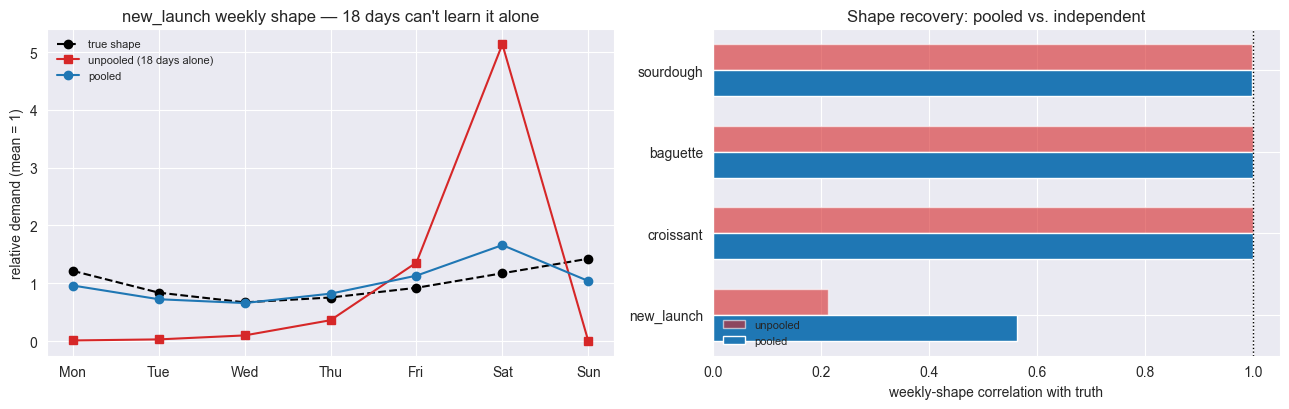

In [6]:
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.plot(DAYS, WsN, "k--o", lw=1.5, label="true shape")
ax.plot(DAYS, unpooled_shape["new_launch"], color="C3", marker="s", label="unpooled (18 days alone)")
ax.plot(DAYS, pooled_shape["new_launch"], color="C0", marker="o", label="pooled")
ax.set_title("new_launch weekly shape — 18 days can't learn it alone")
ax.set_ylabel("relative demand (mean = 1)")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
y = np.arange(len(ITEMS))[::-1]
ax.barh(y + 0.16, shape["unpooled_corr"], height=0.32, color="C3", alpha=0.6, label="unpooled")
ax.barh(y - 0.16, shape["pooled_corr"], height=0.32, color="C0", label="pooled")
ax.axvline(1.0, color="k", ls=":", lw=1)
ax.set_yticks(y, ITEMS)
ax.set_xlim(right=1.05)
ax.set_xlabel("weekly-shape correlation with truth")
ax.set_title("Shape recovery: pooled vs. independent")
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()

The contrast is stark. Fit **on its own** (red), `new_launch`'s 18 days give
the `UnivariateSSM` a badly distorted weekly shape — it invents a huge phantom
Saturday spike and washes the rest out, correlating only weakly with the truth.
Inside the hierarchy (blue) it borrows the shared weekly shape and tracks the real
cycle far better. The data-rich items are the control: pooled ≈ unpooled, both
essentially perfect (~1.0) — with a few months of data an item learns its own
seasonality and pooling barely changes it.

That is partial pooling in one picture: **strong shrinkage where data is scarce,
negligible where it is plentiful** — and it is why, next, `new_launch`'s forecast
shows a sensible weekly cycle it could never have produced from 18 days alone.

## 4. Forecasting and demand distributions

`forecast(periods, scenario=...)` extends every item forward jointly. Because
`promo` is a covariate, we pass its **known future values** for the horizon in the
scenario (for horizons within the promo calendar this needs no separate driver
forecast).

C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1F8FBF62DC0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [forecast_combined]


Output()

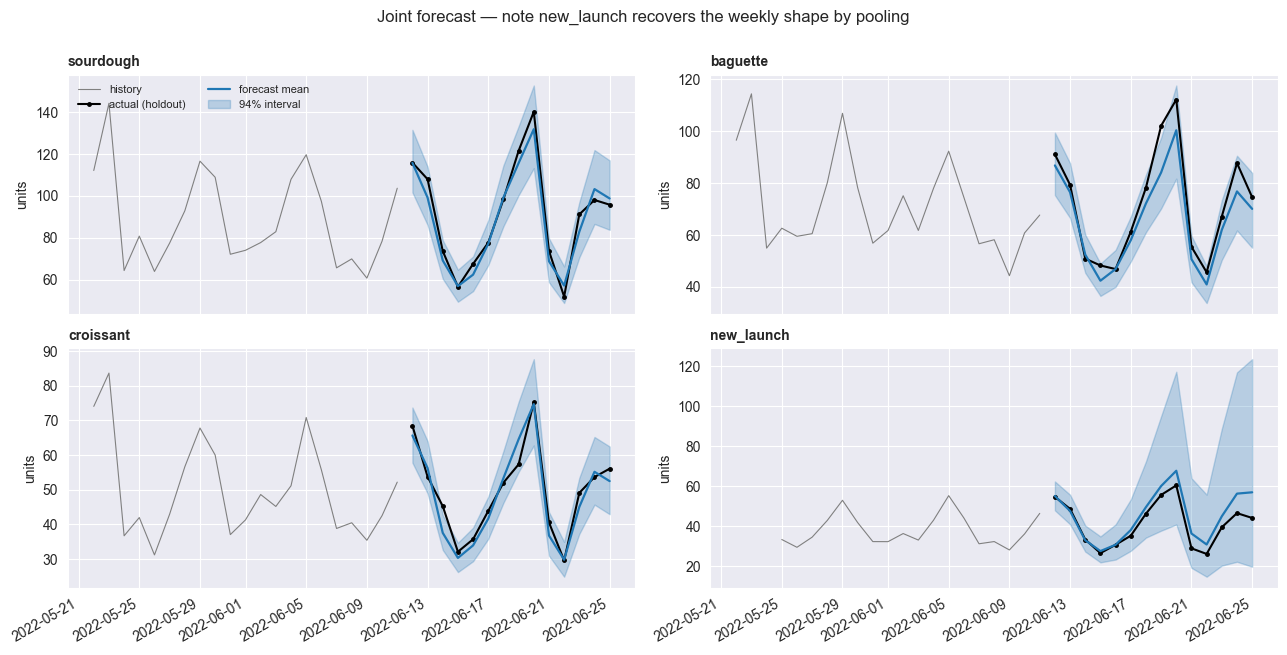

In [7]:
future_promo = full["promo"].to_numpy()[N_FULL:N_FULL + HORIZON]
model.forecast(periods=HORIZON, scenario={"data_promo": future_promo[:, None]})

fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True)
truth_future = full.iloc[N_FULL:N_FULL + HORIZON]
for ax, it in zip(axes.ravel(), ITEMS):
    obs = model.forecast_idata["forecast_observed"].sel(observed_state=it)
    samp = model.inverse_transform(obs.stack(sample=["chain", "draw"]))
    t = model.forecast_idata["time"].values
    mean = samp.mean("sample").values
    lo = samp.quantile(0.03, "sample").values
    hi = samp.quantile(0.97, "sample").values
    hist = panel[it].dropna().tail(21)
    ax.plot(hist.index, hist.values, color="0.5", lw=0.8, label="history")
    ax.plot(t, truth_future[it].values, "k.-", ms=5, label="actual (holdout)")
    ax.plot(t, mean, color="C0", lw=1.6, label="forecast mean")
    ax.fill_between(t, lo, hi, color="C0", alpha=0.25, label="94% interval")
    ax.set_title(it, loc="left", fontsize=10, fontweight="bold")
    ax.set_ylabel("units")
axes[0, 0].legend(loc="upper left", ncols=2, frameon=False, fontsize=8)
fig.suptitle("Joint forecast — note new_launch recovers the weekly shape by pooling", y=1.0)
fig.autofmt_xdate(rotation=30)
fig.tight_layout()

`get_demand_distribution(start, end, item=...)` sums the posterior predictive
over a planning window and returns the full **distribution of total demand** in
original units — exactly what a newsvendor decision needs.

new_launch — week-ahead total demand: mean 281, 90% interval [238, 336]
newsvendor order at CF=0.71: 292 units  (all samples >= 0: True)


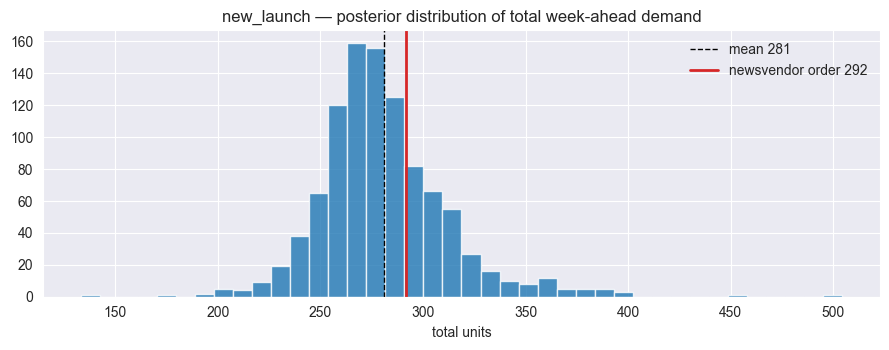

In [8]:
start = str(model.forecast_idata["time"].values[0])[:10]
end = str(model.forecast_idata["time"].values[6])[:10]   # first week of the horizon

# Per-item demand distribution
dd = model.get_demand_distribution(start, end, item="new_launch")
samples = dd["demand"].values.ravel()

# Newsvendor order at a 0.7 critical fractile (see notebook 11) — sale price 8, cost 3, salvage 1
CF = (8 - 3) / (8 - 1)
q_star = float(np.quantile(samples, CF))
print(f"new_launch — week-ahead total demand: mean {samples.mean():.0f}, "
      f"90% interval [{np.quantile(samples,0.05):.0f}, {np.quantile(samples,0.95):.0f}]")
print(f"newsvendor order at CF={CF:.2f}: {q_star:.0f} units  (all samples >= 0: {bool((samples>=0).all())})")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(samples, bins=40, color="C0", alpha=0.8, edgecolor="white")
ax.axvline(samples.mean(), color="k", ls="--", lw=1, label=f"mean {samples.mean():.0f}")
ax.axvline(q_star, color="C3", lw=2, label=f"newsvendor order {q_star:.0f}")
ax.set_title("new_launch — posterior distribution of total week-ahead demand")
ax.set_xlabel("total units"); ax.legend(frameon=False)
fig.tight_layout()

Calling it with `item=None` keeps all items at once (a `demand` array with an
`observed_state` dimension) for portfolio-level use.

> **Integration note.** `ForecastSolver` calls `get_demand_distribution(start, end)`
> without an item, so plugging a multi-item `HierarchicalSSM` straight in would mix
> items. For per-item optimisation, either call `get_demand_distribution(item=...)`
> and apply the critical-fractile rule as above, or wrap a single item — a small
> ForecastSolver adapter for panel forecasters is natural future work.

In [9]:
all_items = model.get_demand_distribution(start, end)          # item=None
print("dims:", dict(all_items["demand"].sizes))
print("mean total week-ahead demand per item:")
print(all_items["demand"].mean(dim=["chain", "draw"]).to_pandas().round(0).to_string())

dims: {'chain': 2, 'draw': 500, 'observed_state': 4}
mean total week-ahead demand per item:
observed_state
sourdough     580.0
baguette      435.0
croissant     319.0
new_launch    281.0


## 5. Changing the priors — without refitting

The pooling behaviour is governed by `HierarchicalSSMPriors`. The two `_sigma`
hyper-priors are the **shrinkage dials**: a *smaller* population spread forces items
to look alike (strong shrinkage), a *larger* one lets them diverge (weak shrinkage).
Every field is a `Prior` you can swap.

In [10]:
from optistock.forecasting import HierarchicalSSMPriors
from optistock.forecasting.priors import Prior

print(HierarchicalSSMPriors())

HierarchicalSSMPriors:
Variable                  Distribution  Parameters          Description
-----------------------------------------------------------------------
initial_state_cov         Gamma         alpha=2, beta=10    Diagonal scale of the initial state covariance (P0_diag)
initial_state             Normal        mu=0.5, sigma=0.5   Per-item initial state values (initial_*)
observation_noise         HalfNormal    sigma=0.05          Per-item measurement noise (sigma_obs)
process_noise             Gamma         alpha=2, beta=50    Per-item process noise for trend / level / slope (sigma_*)
regression_innovation     Gamma         alpha=2, beta=50    Per-item innovation variance for time-varying regression coefs (sigma_beta_*)
seasonal_innovation       Gamma         alpha=2, beta=50    Per-item process noise for seasonal amplitudes (sigma_seasonal)
seasonal_amplitude_mu     Normal        mu=0.0, sigma=0.15  Population mean of per-item seasonal amplitudes (per harmonic)
seasonal_am

In [11]:
# Strong pooling: tight population spread on the promo coefficient and seasonality.
strong_pooling = HierarchicalSSMPriors(
    regression_beta_sigma=Prior("HalfNormal", {"sigma": 0.05},
                                "Tight spread -> items share one promo response"),
    seasonal_amplitude_sigma=Prior("HalfNormal", {"sigma": 0.05},
                                   "Tight spread -> items share one weekly shape"),
)
# Weak pooling: wide spread -> nearly independent items.
weak_pooling = HierarchicalSSMPriors(
    regression_beta_sigma=Prior("HalfNormal", {"sigma": 1.0}, "Wide spread -> promo effects free to differ"),
)

# Wiring only — pass at construction, build the graph. No fit() call here.
strong_model = HierarchicalSSM(panel, items=ITEMS, exog=["promo"],
                               log_transform=True, priors=strong_pooling)
strong_model.build_model(seasonal_period=7, seasonal_harmonics=2)
print("Model built with custom priors (not fitted). Pooling sigma in use:",
      strong_model.priors.regression_beta_sigma.params)

                                           Model Requirements                                            
                                                                                                         
  Variable              Shape       Constraints                                              Dimensions  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (4, 2)                               ('endog_level_trend', 'state_level_trend')  
  sigma_level_trend     (4, 1)      Positive                 ('endog_level_trend', 'shock_level_trend')  
  beta_promo            (4, 1)                                           ('endog_promo', 'state_promo')  
  params_seasonal       (4, 4)                                     ('endog_seasonal', 'state_seasonal')  
  sigma_obs             (4,)        Positive                                             ('endog_obs',)  
  P0                    (28, 28)    Positive semi-definite                       ('state', 'state_aux')  
                                                                                                         
  data_promo            (None, 1)   pm.Data                                     ('time', 'state_promo')  
                                                                                                         
         These parameters should be assigned priors inside a PyMC model block before calling the         
                                     build_statespace_graph method.                                      

Model built with custom priors (not fitted). Pooling sigma in use: {'sigma': 0.05}


To *see* what the pooling prior implies before spending any compute, sample the
hierarchy's prior directly in numpy: draw `beta_mu`, `beta_sigma`, and the
per-item offsets, and look at the spread of implied per-item promo lifts. This is
purely the prior — no data, no MCMC.

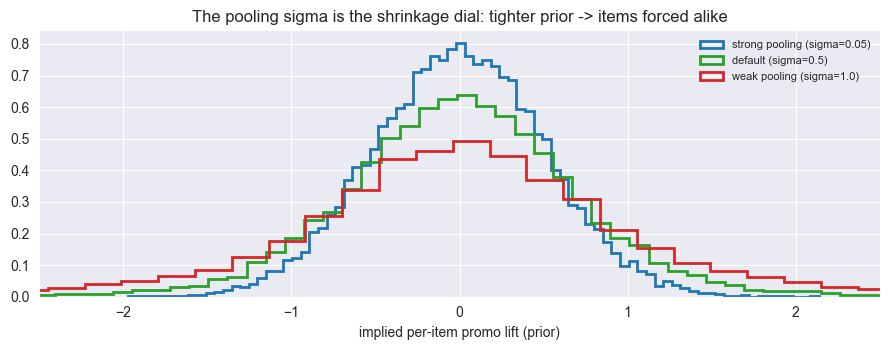

In [12]:
def implied_item_lifts(beta_sigma_scale, n=20000):
    mu = np.random.normal(0.0, 0.5, n)                      # regression_beta_mu (default)
    sigma = np.abs(np.random.normal(0.0, beta_sigma_scale, n))  # HalfNormal(beta_sigma_scale)
    z = np.random.normal(0.0, 1.0, n)                       # per-item standardised offset
    return mu + sigma * z

fig, ax = plt.subplots(figsize=(9, 3.6))
for scale, label, c in [(0.05, "strong pooling (sigma=0.05)", "C0"),
                        (0.5, "default (sigma=0.5)", "C2"),
                        (1.0, "weak pooling (sigma=1.0)", "C3")]:
    ax.hist(implied_item_lifts(scale), bins=80, density=True, histtype="step",
            lw=2, color=c, label=label)
ax.set_xlim(-2.5, 2.5)
ax.set_xlabel("implied per-item promo lift (prior)")
ax.set_title("The pooling sigma is the shrinkage dial: tighter prior -> items forced alike")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

**Takeaways.** `HierarchicalSSM` fits a whole panel jointly and partially pools
the seasonal shape and covariate coefficients, so a data-starved item borrows
strength — recovering a sensible promo response and weekly cycle it could never
estimate alone (§3–4). Forecasts and per-item demand distributions come out
non-negative and ready for a newsvendor decision (§4). The pooling strength is a
prior you set: the `_sigma` hyper-priors dial shrinkage from "all items identical"
to "fully independent" (§5).